In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

In [3]:
data_path = "./Data/"

In [4]:
# data.csv – основные показатели по словам
data = pd.read_csv(data_path + "data.csv", sep=';', encoding='utf-8')

# participants.csv – анкеты детей
participants = pd.read_csv(data_path + "participants.csv", sep=',', encoding='utf-8')

# sentences.csv – информация о предложениях
sentences = pd.read_csv(data_path + "sentences.csv", sep=',', encoding='utf-8')

# words.csv – детальные лингвистические характеристики слов
words = pd.read_csv(data_path + "words.csv", sep=',', encoding='utf-8')

# IA_children_norm.csv – сырые данные по зонам интереса
ia_raw = pd.read_csv(data_path + "IA_children_norm.csv", sep=',', encoding='utf-8')

In [5]:
print("=== data.csv ===")
print(data.shape)
data.head()

=== data.csv ===
(43443, 22)


,SubjID,sent_text,IA_ID,IA_FIRST_FIXATION_DURATION,IA_FIRST_RUN_DWELL_TIME,IA_DWELL_TIME,IA_SKIP,IA_REGRESSION_OUT_FULL,ACCURACY,one_fix,twoplus_fix,landing,fsa,item.id,word.id,rel.position,POS,length,frequency,predictability,Grade,Sound_change
0,m10,"Причиной аварии был мобильный телефон, который...",2,136,136,1734,0,1,-1,0,1,0.030833,1.99,14,аварии,0.250,NOUN,6,0.072733,0.028571,2,0.62
1,m10,"Причиной аварии был мобильный телефон, который...",3,294,294,988,0,0,-1,0,1,0.086667,1.24,14,был,0.375,VERB,3,34.939520,0.085714,2,0.62
2,m10,"Причиной аварии был мобильный телефон, который...",4,312,312,1922,0,1,-1,0,1,-0.008287,1.22,14,мобильный,0.500,ADJ,9,0.038098,0.057143,2,0.62
3,m10,"Причиной аварии был мобильный телефон, который...",5,230,581,581,0,0,-1,0,1,0.124841,1.58,14,телефон,0.625,NOUN,7,0.623425,0.942857,2,0.62
4,m10,"Причиной аварии был мобильный телефон, который...",6,368,522,522,0,0,-1,0,1,0.121127,2.00,14,который,0.750,ADJ,7,10.300370,0.371429,2,0.62


In [6]:
print("\n=== participants.csv ===")
print(participants.shape)
participants.head()


=== participants.csv ===
(222, 8)


,SubjID,Sex,Grade,Age,IQ,Reading_speed,Sound_change,Eyetracker
0,28_norm1,fem,1,7,35,93,0.95,1000Plus
1,29_norm1,fem,1,8,34,33,0.71,1000Plus
2,34_norm1,fem,1,7,34,79,0.95,1000Plus
3,36_norm1,fem,1,7,32,74,0.83,1000Plus
4,42_norm1,fem,1,7,30,113,1.00,1000Plus


In [7]:
print("\n=== sentences.csv ===")
print(sentences.shape)
sentences.head()


=== sentences.csv ===
(33, 6)


,sentence.id,sent_text,type,question,response_correct,response_incorrect
0,1,В каждом углу комнаты сидели по две кошки.,practice,Где сидели кошки?,в комнате,на улице
1,2,Петя никак не мог доделать домашнюю работу.,practice,Кто не мог доделать домашнюю работу?,Петя,Коля
2,3,Ей никак не суметь испечь такой торт самой.,practice,Что она может испечь?,торт,пирог
3,4,"У них был уютный, спокойный дом, крепкая семья.",test,Они часто ругались?,нет,да
4,5,"Дорога вела в глухой лес, петляя по склонам.",test,NaN,NaN,NaN


In [8]:
print("\n=== words.csv ===")
print(words.shape)
words.head()


=== words.csv ===
(227, 16)


,item.id,word.id,sent_text,sentence.length,IA_LABEL,word.serial.no,rel.position,number.morphemes,POS,length,next.length,prev.length,frequency,prev.freq,next.freq,predictability
0,14,аварии,"Причиной аварии был мобильный телефон, который...",8,аварии,2,0.250000,2,NOUN,6,3,8,0.072733,0.083123,34.939520,0.028571
1,11,андрей,"В магазине Андрей купил молоко, сметану, творог.",7,Андрей,3,0.428571,1,NOUN,6,5,8,0.661523,0.450252,0.737720,0.014000
2,23,бант,Коробку с подарками украшал бант огромного раз...,7,бант,5,0.714286,1,NOUN,4,9,7,0.076196,0.010390,0.238980,0.176471
3,7,берегам,"На кустах, росших по берегам реки, появились л...",8,берегам,5,0.625000,2,NOUN,7,4,2,0.128149,77.772296,2.358625,0.032258
4,27,брошенный,Брошенный мальчиком снежок попал в окно второг...,8,Брошенный,1,0.125000,3,ADJ,9,9,0,0.096977,NaN,0.439861,NaN


In [9]:
print("\n=== IA_children_norm.csv ===")
print(ia_raw.shape)
ia_raw.head()


=== IA_children_norm.csv ===
(50063, 34)


,sent_text,id,IA_LABEL,IA_DWELL_TIME,IA_FIRST_FIXATION_DURATION,IA_FIRST_RUN_DWELL_TIME,IA_REGRESSION_PATH_DURATION,IA_FIRST_FIXATION_X,IA_FIRST_FIXATION_Y,IA_SKIP,IA_REGRESSION_IN,IA_REGRESSION_OUT,IA_REGRESSION_OUT_FULL,IA_FIXATION_COUNT,IA_FIRST_SACCADE_AMPLITUDE,IA_RIGHT,IA_LEFT,ACCURACY,IA_FIRST_RUN_FIXATION_COUNT,IA_FIRST_RUN_LANDING_POSITION,IA_FIRST_RUN_LAUNCH_SITE,IA_FIRST_SACCADE_ANGLE,IA_REGRESSION_IN_COUNT,IA_REGRESSION_OUT_COUNT,IA_REGRESSION_OUT_FULL_COUNT,IA_RUN_COUNT,IA_SECOND_FIXATION_DURATION,IA_SECOND_RUN_DWELL_TIME,INTEREST_AREA_FIXATION_SEQUENCE,TRIAL_DWELL_TIME,TRIAL_FIXATION_COUNT,TRIAL_INDEX,IA_ID,SubjID
0,"Причиной аварии был мобильный телефон, который...",14,Причиной,4261,300,1839,1839,"130,10","525,40",0,1,0,0,14,.,317,120,-1,6,"10,10",.,.,1,0,0,2,226,2422,"[2, 3, 2, 3, 4, 5, 4, 5, 4, 5, 6, 7, 8, 9, 0]","13466,00",46,1,1,m10
1,"Причиной аварии был мобильный телефон, который...",14,аварии,1734,136,136,4156,"330,70","549,90",0,0,1,1,6,"1,99",457,317,-1,1,"13,70","115,00","-2,35",0,1,1,2,426,1598,"[2, 3, 2, 3, 4, 5, 4, 5, 4, 5, 6, 7, 8, 9, 0]","13466,00",46,1,2,m10
2,"Причиной аварии был мобильный телефон, который...",14,был,988,294,294,294,"472,20","542,20",0,1,0,0,4,"1,24",537,457,-1,1,"15,20","47,90","9,86",2,0,0,3,241,241,"[2, 3, 2, 3, 4, 5, 4, 5, 4, 5, 6, 7, 8, 9, 0]","13466,00",46,1,3,m10
3,"Причиной аварии был мобильный телефон, который...",14,мобильный,1922,312,312,2616,"545,50","541,80",0,0,1,1,6,"1,22",738,537,-1,1,"8,50","64,80","10,75",0,2,2,3,241,241,"[2, 3, 2, 3, 4, 5, 4, 5, 4, 5, 6, 7, 8, 9, 0]","13466,00",46,1,4,m10
4,"Причиной аварии был мобильный телефон, который...",14,"телефон,",581,230,581,581,"767,60","540,70",0,0,0,0,3,"1,58",915,738,-1,3,"29,60","62,60","8,22",0,0,0,1,154,.,"[2, 3, 2, 3, 4, 5, 4, 5, 4, 5, 6, 7, 8, 9, 0]","13466,00",46,1,5,m10


### Объединяем data и participants по SubjID

In [10]:

df = pd.merge(data, participants, on='SubjID', how='left')
print("Размер после объединения:", df.shape)
df.head()

Размер после объединения: (43443, 29)


,SubjID,sent_text,IA_ID,IA_FIRST_FIXATION_DURATION,IA_FIRST_RUN_DWELL_TIME,IA_DWELL_TIME,IA_SKIP,IA_REGRESSION_OUT_FULL,ACCURACY,one_fix,twoplus_fix,landing,fsa,item.id,word.id,rel.position,POS,length,frequency,predictability,Grade_x,Sound_change_x,Sex,Grade_y,Age,IQ,Reading_speed,Sound_change_y,Eyetracker
0,m10,"Причиной аварии был мобильный телефон, который...",2,136,136,1734,0,1,-1,0,1,0.030833,1.99,14,аварии,0.250,NOUN,6,0.072733,0.028571,2,0.62,masc,2,8,34,63,0.62,PortableDuo
1,m10,"Причиной аварии был мобильный телефон, который...",3,294,294,988,0,0,-1,0,1,0.086667,1.24,14,был,0.375,VERB,3,34.939520,0.085714,2,0.62,masc,2,8,34,63,0.62,PortableDuo
2,m10,"Причиной аварии был мобильный телефон, который...",4,312,312,1922,0,1,-1,0,1,-0.008287,1.22,14,мобильный,0.500,ADJ,9,0.038098,0.057143,2,0.62,masc,2,8,34,63,0.62,PortableDuo
3,m10,"Причиной аварии был мобильный телефон, который...",5,230,581,581,0,0,-1,0,1,0.124841,1.58,14,телефон,0.625,NOUN,7,0.623425,0.942857,2,0.62,masc,2,8,34,63,0.62,PortableDuo
4,m10,"Причиной аварии был мобильный телефон, который...",6,368,522,522,0,0,-1,0,1,0.121127,2.00,14,который,0.750,ADJ,7,10.300370,0.371429,2,0.62,masc,2,8,34,63,0.62,PortableDuo


### Теперь у нас есть характеристики каждого ребёнка (Age, IQ, Reading_speed, Sound_change, Grade) рядом с показателями чтения каждого слова.


In [11]:
# Основные зависимые переменные (время чтения, пропуски, регрессии)
dep_vars = ['IA_DWELL_TIME', 'IA_FIRST_FIXATION_DURATION', 
            'IA_FIRST_RUN_DWELL_TIME', 'IA_SKIP', 'IA_REGRESSION_OUT_FULL']

df[dep_vars].describe()

,IA_DWELL_TIME,IA_SKIP
count,43443.000000,43443.000000
mean,723.047165,0.120549
std,843.650500,0.325606
min,0.000000,0.000000
25%,263.000000,0.000000
50%,484.000000,0.000000
75%,877.000000,0.000000
max,17451.000000,1.000000


### Распределение времени фиксации

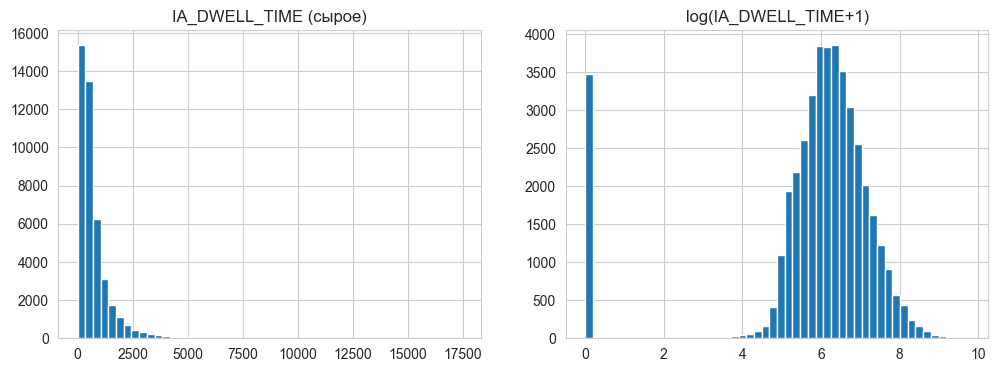

In [12]:

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
df['IA_DWELL_TIME'].hist(bins=50)
plt.title('IA_DWELL_TIME (сырое)')
plt.subplot(1,2,2)
np.log(df['IA_DWELL_TIME']+1).hist(bins=50)
plt.title('log(IA_DWELL_TIME+1)')
plt.show()

1. Левый график: IA_DWELL_TIME (время фиксации на слове в мс)

Это гистограмма исходных данных.

Тип распределения: Сильно выраженное положительное смещение (right-skewed distribution). 

Большинство значений сосредоточено в левой части (короткие фиксации), а вправо уходит длинный «хвост» из редких, но очень длительных фиксаций.

Особенности: Данные распределены неравномерно. Работать с такими данными в «сыром» виде сложно, так как многие статистические методы (например, t-тест или линейная регрессия) предполагают нормальное распределение.

2. Правый график: log(IA_DWELL_TIME + 1)

Это гистограмма тех же данных, но после применения логарифмического преобразования.

Зачем это сделано: Логарифмирование «сжимает» большие значения и «растягивает» маленькие. Добавление единицы (+1) — стандартная практика, чтобы избежать ошибки при логарифмировании нулевых значений ($log(0)$ не определен).

Тип распределения: Теперь основная масса данных напоминает нормальное распределение (колоколообразную кривую).

Аномалия слева: Мы видим высокий отдельный столбец в районе нуля. Это говорит о том, что в данных очень много нулевых значений (случаев, когда фиксации вообще не было). Это те значения, когда слово было пропущено (взглядом, возможно, тк оно было предсказано читателем и прочитано пролетающим взглядом)

In [13]:
# Категориальные переменные: POS (часть речи), Grade (класс), Sex
print(df['POS'].value_counts())
print(df['Grade_x'].value_counts())
print(df['Grade_y'].value_counts())
print(df['Sex'].value_counts())

POS
NOUN        17809
VERB         9716
ADJ          6642
FUNCTION     5069
ADV          2437
PRONOUN      1770
Name: count, dtype: int64
Grade_x
1    9834
2    7832
4    7683
3    7289
5    6077
6    4728
Name: count, dtype: int64
Grade_y
1    9834
2    7832
4    7683
3    7289
5    6077
6    4728
Name: count, dtype: int64
Sex
masc    22838
fem     20605
Name: count, dtype: int64


### Зависимость времени фиксации от длины слова

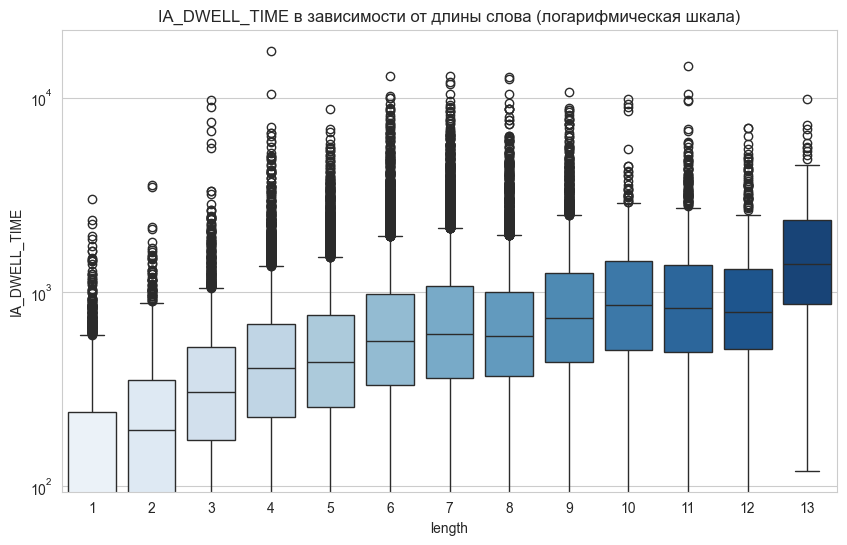

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='length', y='IA_DWELL_TIME', palette='Blues')
plt.yscale('log')
plt.title('IA_DWELL_TIME в зависимости от длины слова (логарифмическая шкала)')
plt.show()

Положительная корреляция: Наблюдается четкая тенденция: чем длиннее слово (ось X), тем выше поднимаются «ящики» (ось Y). \

Это логично — на длинные слова человек смотрит дольше, так как их сложнее обрабатывать когнитивно.Медиана (горизонтальная линия внутри каждого ящика): Она стабильно растет с увеличением длины слова. Например, для слова длиной «1» медиана находится чуть выше $10^2$ (около 150–200 мс), а для слова длиной «13» она уже приближается к $10^3$ (около 800–900 мс).\

Межквартильный размах (тело «ящика»): Высота синих прямоугольников показывает разброс «типичных» значений (центральные 50% данных). Видно, что с ростом длины слова увеличивается и вариативность — люди могут прочесть длинное слово как относительно быстро, так и очень долго.\
Выбросы (точки над «усами»): Их очень много, особенно в верхней части ($10^3$ — $10^4$). Это те самые «хвосты» распределения из предыдущего анализа — аномально долгие фиксации, которые могут быть вызваны тем, что читатель отвлекся или слово было крайне сложным.

График подтверждает гипотезу о том, что длина слова является значимым фактором, влияющим на время обработки текста.

Однако слова длиной 7 и 8: их медианы почти на одном уровне. Это может указывать на то, что после определенного порога (например, когда слово перестает восприниматься целостно и начинает разбиваться на морфемы) динамика роста времени фиксации может меняться.

### Зависимость от частоты слова (log frequency)

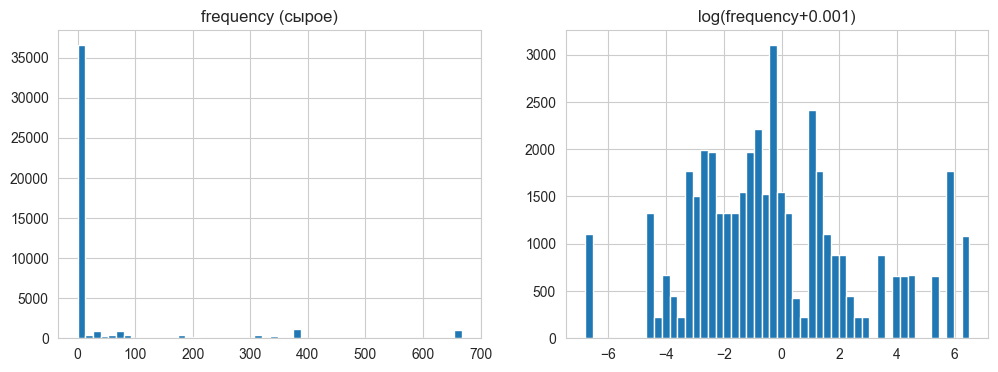

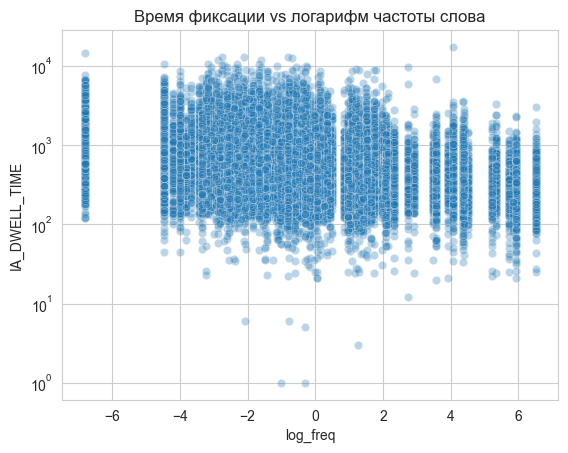

In [15]:
df['log_freq'] = np.log(df['frequency'] + 0.001)  # сдвиг для нулевых частот

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
df['frequency'].hist(bins=50)
plt.title('frequency (сырое)')
plt.subplot(1,2,2)
df['log_freq'].hist(bins=50)
plt.title('log(frequency+0.001)')
plt.show()

sns.scatterplot(data=df, x='log_freq', y='IA_DWELL_TIME', alpha=0.3)
plt.yscale('log')
plt.title('Время фиксации vs логарифм частоты слова')
plt.show()

Отрицательная корреляция: В отличие от предыдущего графика, здесь наблюдается обратная зависимость. Хотя данных очень много (плотное «облако»), общая масса точек плавно снижается слева направо.

Смысл зависимости: * Слева (низкая частота): Редкие слова (малые значения log_freq). На них точки забираются выше по оси Y — люди тратят на них больше времени, так как они менее узнаваемы.

Справа (высокая частота): Часто встречающиеся слова. Здесь «облако» заметно ниже — мозг распознает их мгновенно, поэтому время фиксации падает.

Чем чаще слово встречается в языке, тем быстрее человек его обрабатывает.

### Пропуск слова в зависимости от частоты и длины

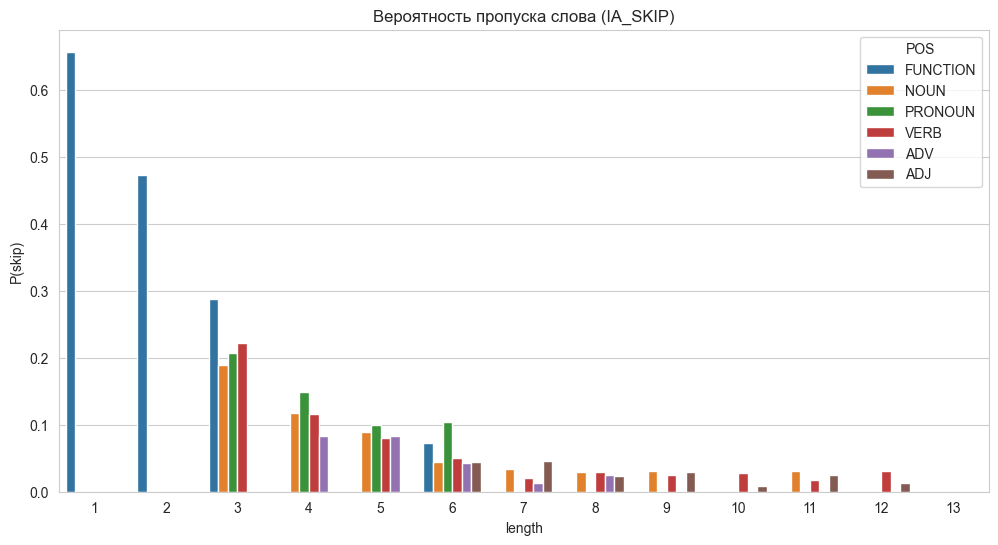

In [41]:
df_skip = df.groupby(['length', 'POS'])['IA_SKIP'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=df_skip, x='length', y='IA_SKIP', hue='POS')
plt.title('Вероятность пропуска слова (IA_SKIP)')
plt.ylabel('P(skip)')
plt.show()

Экономия ресурсов: Чтение — это процесс оптимизации. Мозг «пролетает» мимо коротких и грамматически предсказуемых слов (FUNCTION), чтобы сэкономить время для обработки длинных и информативных слов (NOUN, VERB).

Эффект предсказуемости: Чем короче слово, тем выше вероятность, что оно будет распознано периферийным зрением без прямой фиксации.

### Сравним время фиксации для детей с разной скоростью чтения (Reading_speed)

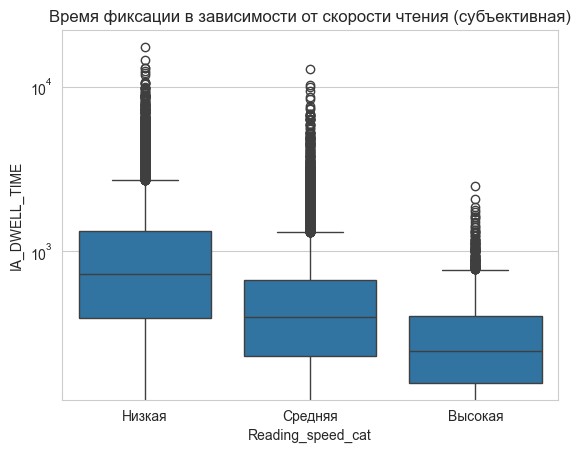

In [42]:
df['Reading_speed_cat'] = pd.cut(df['Reading_speed'], bins=3, labels=['Низкая', 'Средняя', 'Высокая'])
sns.boxplot(data=df, x='Reading_speed_cat', y='IA_DWELL_TIME')
plt.yscale('log')
plt.title('Время фиксации в зависимости от скорости чтения (субъективная)')
plt.show()

Когнитивная нагрузка: Высокая скорость чтения напрямую связана с быстротой узнавания слов. Опытным чтецам требуется почти в два раза меньше времени на одну фиксацию, чтобы извлечь смысл.

Автоматизм: Компактность «ящика» у быстрых чтецов говорит о сформированном навыке — их глаз двигается в стабильном ритме.

### Влияние возраста (Age) и IQ на время фиксации на слове

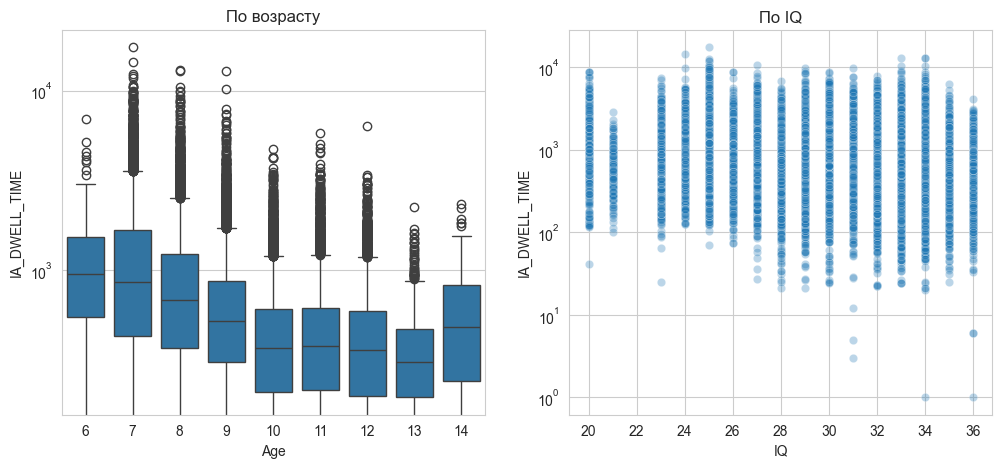

In [43]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=df, x='Age', y='IA_DWELL_TIME')
plt.yscale('log')
plt.title('По возрасту')
plt.subplot(1,2,2)
sns.scatterplot(data=df, x='IQ', y='IA_DWELL_TIME', alpha=0.3)
plt.yscale('log')
plt.title('По IQ')
plt.show()

#### Age
Тенденция: Наблюдается явное снижение времени фиксации с возрастом. Это классическая картина созревания когнитивных функций и навыков чтения.

#### IQ
Распределение: На первый взгляд данные выглядят как плотное «облако» без ярко выраженного наклона.

Интерпретация: В отличие от возраста, IQ не дает такой линейной и сильной зависимости. Точки распределены довольно равномерно по всей шкале IQ (от 20 до 36 в данных теста).

### Sound_change – изменение громкости чтения


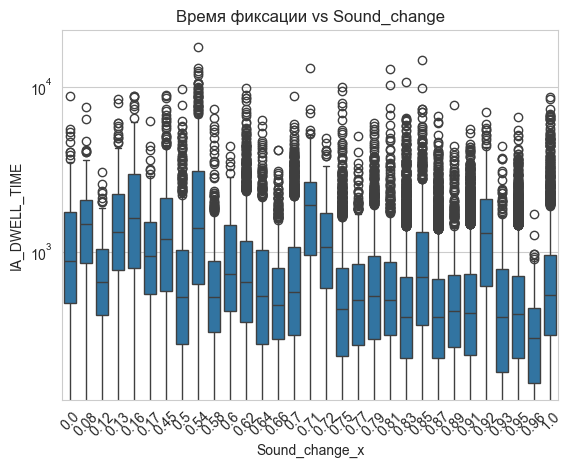

In [44]:
sns.boxplot(data=df, x='Sound_change_x', y='IA_DWELL_TIME')
plt.yscale('log')
plt.title('Время фиксации vs Sound_change')
plt.xticks(rotation=45)
plt.show()

Сложная зависимость: Изменение громкости не влияет на чтение так же прямолинейно, как сложность текста. Вероятно, это нелинейный фактор, который срабатывает только в определенные моменты (например, когда звук становится слишком тихим или слишком резким).

Индивидуальные реакции: Огромное количество выбросов говорит о том, что разные дети реагируют на изменение звука по-разному: кто-то игнорирует шум, а кто-то полностью теряет концентрацию.

### Выберем числовые колонки для корреляционной матрицы

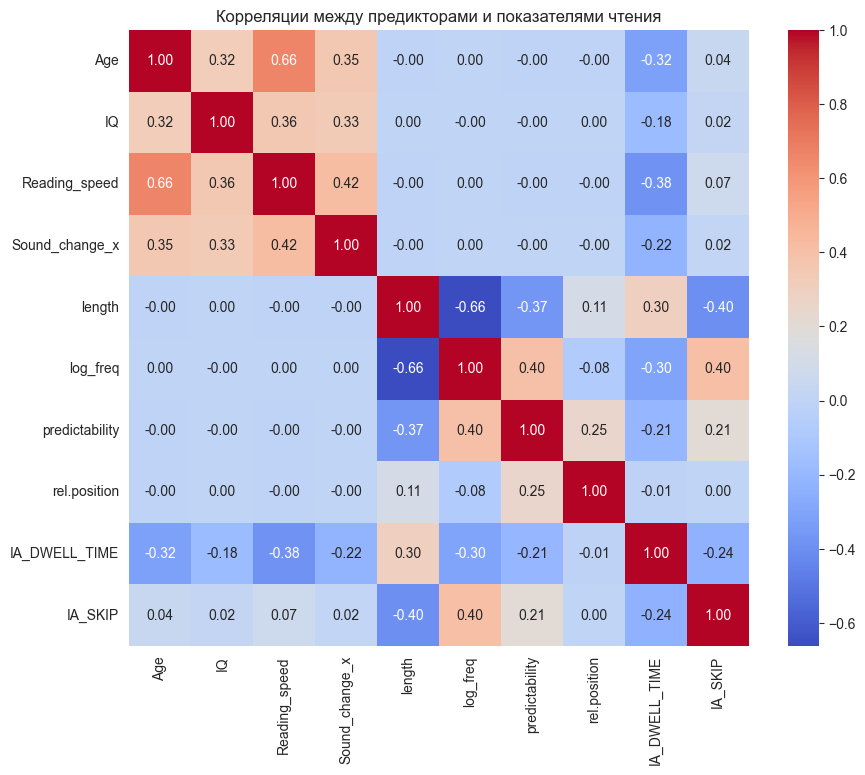

In [45]:
numeric_cols = ['Age', 'IQ', 'Reading_speed', 'Sound_change_x', 'length', 'log_freq', 
                'predictability', 'rel.position', 'IA_DWELL_TIME', 'IA_SKIP']
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляции между предикторами и показателями чтения')
plt.show()

Age – возраст ребенка (в годах)

IQ – коэффициент интеллекта (числовой показатель)

Reading_speed – скорость чтения (вероятно, слов в минуту)

Sound_change_x – изменение громкости чтения

length – длина слова в буквах или символах

log_freq – натуральный логарифм частоты слова в языке (log(frequency+constant)). Чем выше, тем слово встречается чаще, обычно читается быстрее.

predictability – предсказуемость слова в контексте предложения (вероятность от 0 до 1). Более предсказуемые слова пропускаются или читаются быстрее.

rel.position – относительная позиция слова в предложении (например, номер слова деленный на длину предложения). Влияет на внимание и регрессии.

IA_DWELL_TIME – общее время (в миллисекундах), которое взгляд провел на зоне интереса (слове) за все просмотры

IA_SKIP – бинарный показатель: пропущено ли слово при первом чтении (1 - пропущено, 0 - не пропущено).

______
1. *Что больше всего влияет на время фиксации (IA_DWELL_TIME)?*
______

Reading_speed (-0.38): Самая сильная отрицательная связь. Чем выше скорость чтения, тем меньше времени тратится на слово. Это подтверждает, что навык чтения — главный индивидуальный фактор.

Age (-0.32): С возрастом время фиксации падает. Дети становятся опытнее и читают быстрее.

length (0.30): Чем длиннее слово, тем дольше на нем задерживается взгляд.

log_freq (-0.30): Чем чаще встречается слово (выше логарифм частоты), тем быстрее оно обрабатывается.

predictability (-0.21): Если слово предсказуемо из контекста, время фиксации на нем сокращается.
______
2. *Что влияет на пропуск слова (IA_SKIP)?*
______

length (-0.40): Самая сильная связь в этой строке. Длинные слова пропускают значительно реже.

log_freq (0.40): Частые слова пропускаются гораздо чаще. Это логично: мозг узнает «и», «в», «на» периферийным зрением.

predictability (0.21): Предсказуемые слова пропускаются чаще, так как мозг «угадывает» их, не фиксируясь.
______
3. *Взаимосвязь между характеристиками текста*
______

В центре матрицы виден интересный блок:

length vs log_freq (-0.66): Сильная отрицательная корреляция. Она отражает закон Ципфа: короткие слова в языке почти всегда являются самыми частотными (предлоги, союзы), а длинные — редкими.

length vs predictability (-0.37): Длинные слова обычно менее предсказуемы, чем короткие.
______
4. *Взаимосвязь между характеристиками ребенка*
______

Age vs Reading_speed (0.66): Сильная положительная связь. Ожидаемо: с возрастом скорость чтения у детей значительно растет.

Age vs IQ (0.32): Есть слабая положительная связь, но она гораздо слабее, чем связь возраста с навыком чтения.

Sound_change_x: Интересно, что этот параметр почти не коррелирует ни с чем (нулевые значения), кроме возраста и скорости чтения (около 0.35–0.42). Это может означать, что сама громкость чтения — это индивидуальная характеристика, которая растет вместе с общим развитием ребенка.


### Сохраним объединённый датафрейм для дальнейшей работы

In [46]:
df.to_csv("merged_data.csv", index=False)
print("Объединённые данные сохранены в merged_data.csv")

Объединённые данные сохранены в merged_data.csv


## Анализ каждого класса


=== СТАТИСТИКА ПО КЛАССАМ 1–6 (СЫРОЕ ВРЕМЯ ФИКСАЦИИ) ===

Класс 1:
  Количество детей: 51
  Количество наблюдений (слов): 9834
  Среднее время фиксации (мс): 1306.70
  Медианное время фиксации (мс): 899.00
  Стандартное отклонение (мс): 1298.03
  Средний пропуск слов (IA_SKIP): 0.05
  Среднее число регрессий (IA_REGRESSION_OUT_FULL): 0.26
  Средняя скорость чтения (Reading_speed): 63.86
  Средний IQ: 29.80
  Средний Sound_change: 0.69
  Средняя длина слова (букв): 6.02
  Средняя предсказуемость: 0.16

Класс 2:
  Количество детей: 40
  Количество наблюдений (слов): 7832
  Среднее время фиксации (мс): 863.80
  Медианное время фиксации (мс): 642.00
  Стандартное отклонение (мс): 782.21
  Средний пропуск слов (IA_SKIP): 0.04
  Среднее число регрессий (IA_REGRESSION_OUT_FULL): 0.23
  Средняя скорость чтения (Reading_speed): 78.83
  Средний IQ: 30.99
  Средний Sound_change: 0.77
  Средняя длина слова (букв): 6.06
  Средняя предсказуемость: 0.16

Класс 3:
  Количество детей: 37
  Количество 

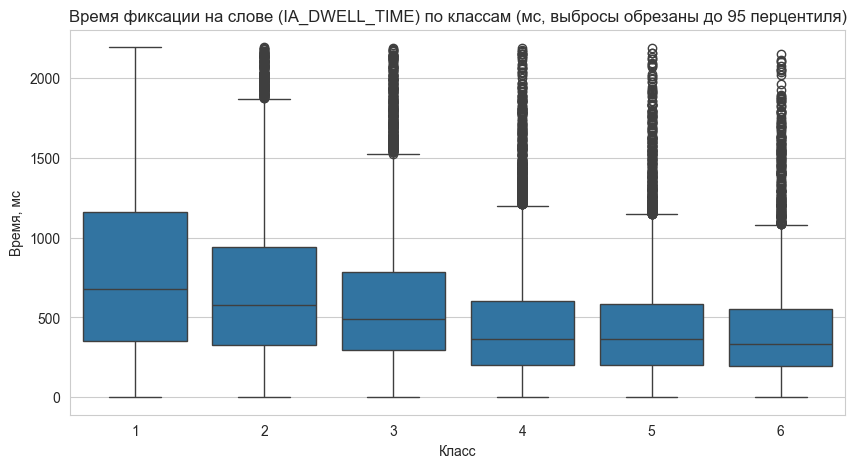

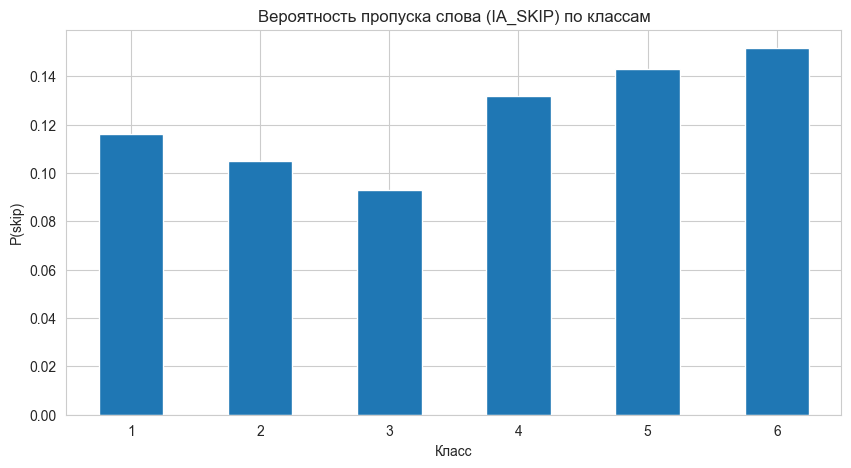

<Figure size 1200x600 with 0 Axes>

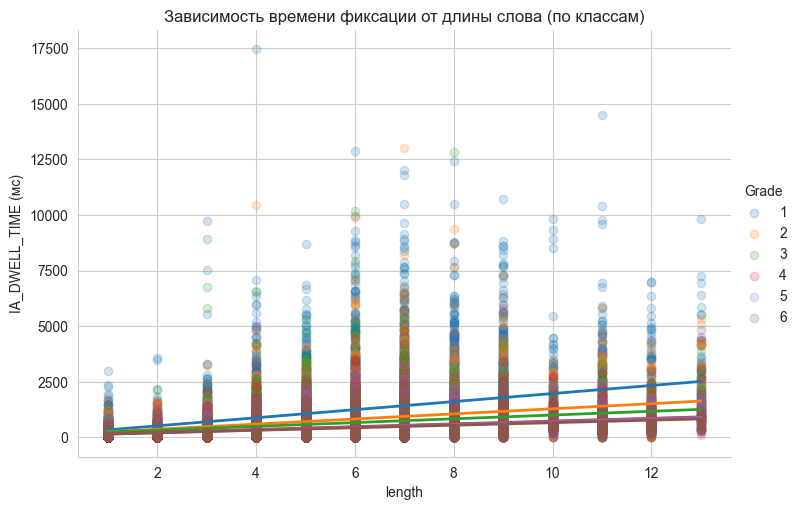

In [47]:
# Определяем колонку Grade
if 'Grade_y' in df.columns:
    df['Grade'] = df['Grade_y']
elif 'Grade_x' in df.columns:
    df['Grade'] = df['Grade_x']
elif 'Grade' in data.columns:
    df['Grade'] = data['Grade']

# Очистка
df = df.dropna(subset=['Grade'])
df['Grade'] = df['Grade'].astype(int)
df = df[df['Grade'].between(1, 6)]

# ------------------------------
# Приведение всех числовых колонок к числовому типу
# ------------------------------
numeric_cols = ['IA_DWELL_TIME', 'IA_SKIP', 'IA_REGRESSION_OUT_FULL', 
                'Reading_speed', 'IQ', 'Sound_change', 'length', 'frequency', 'predictability']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # нечисловое -> NaN

# ------------------------------
# Функция анализа одного класса (сырое время)
# ------------------------------
def analyze_grade(df, grade):
    subset = df[df['Grade'] == grade].copy()
    if subset.empty:
        print(f"\n⚠️ Класс {grade} отсутствует в данных.")
        return None
    
    # Удаляем строки с NaN в ключевых колонках
    subset_clean = subset.dropna(subset=['IA_DWELL_TIME', 'IA_SKIP', 'IA_REGRESSION_OUT_FULL', 
                                         'Reading_speed', 'IQ', 'Sound_change_x', 'length', 'predictability'])
    if subset_clean.empty:
        print(f"\n⚠️ Класс {grade} не имеет числовых данных после очистки.")
        return None
    
    stats = {
        'Количество детей': subset['SubjID'].nunique(),
        'Количество наблюдений (слов)': len(subset),
        'Среднее время фиксации (мс)': subset_clean['IA_DWELL_TIME'].mean(),
        'Медианное время фиксации (мс)': subset_clean['IA_DWELL_TIME'].median(),
        'Стандартное отклонение (мс)': subset_clean['IA_DWELL_TIME'].std(),
        'Средний пропуск слов (IA_SKIP)': subset_clean['IA_SKIP'].mean(),
        'Среднее число регрессий (IA_REGRESSION_OUT_FULL)': subset_clean['IA_REGRESSION_OUT_FULL'].mean(),
        'Средняя скорость чтения (Reading_speed)': subset_clean['Reading_speed'].mean(),
        'Средний IQ': subset_clean['IQ'].mean(),
        'Средний Sound_change': subset_clean['Sound_change_x'].mean(),
        'Средняя длина слова (букв)': subset_clean['length'].mean(),
        'Средняя предсказуемость': subset_clean['predictability'].mean()
    }
    return stats

# ------------------------------
# Сбор статистики для классов 1–6
# ------------------------------
results = {}
for g in range(1, 7):
    stats = analyze_grade(df, g)
    results[g] = stats

print("\n=== СТАТИСТИКА ПО КЛАССАМ 1–6 (СЫРОЕ ВРЕМЯ ФИКСАЦИИ) ===\n")
for g, stats in results.items():
    if stats is None:
        print(f"Класс {g}: данные отсутствуют")
    else:
        print(f"Класс {g}:")
        for key, val in stats.items():
            if isinstance(val, float):
                print(f"  {key}: {val:.2f}")
            else:
                print(f"  {key}: {val}")
        print()

# ------------------------------
# Графики с сырым временем (без логарифма)
# ------------------------------
if not df.empty and df['IA_DWELL_TIME'].notna().any():
    # 1. Ящик с усами для сырого времени (можно обрезать выбросы для наглядности)
    plt.figure(figsize=(10,5))
    # Ограничим ось Y 95-м процентилем, чтобы убрать очень большие выбросы
    upper_lim = df['IA_DWELL_TIME'].quantile(0.95)
    sns.boxplot(data=df[df['IA_DWELL_TIME'] <= upper_lim], x='Grade', y='IA_DWELL_TIME', order=list(range(1,7)))
    plt.title('Время фиксации на слове (IA_DWELL_TIME) по классам (мс, выбросы обрезаны до 95 перцентиля)')
    plt.ylabel('Время, мс')
    plt.xlabel('Класс')
    plt.xticks(ticks=range(6), labels=[1,2,3,4,5,6])
    plt.show()
    
    # 2. Столбцы вероятности пропуска слова
    plt.figure(figsize=(10,5))
    skip_by_grade = df.groupby('Grade')['IA_SKIP'].mean().reindex(range(1,7))
    skip_by_grade.plot(kind='bar')
    plt.title('Вероятность пропуска слова (IA_SKIP) по классам')
    plt.ylabel('P(skip)')
    plt.xlabel('Класс')
    plt.xticks(rotation=0)
    plt.show()
    
    # 3. Влияние длины слова на время фиксации (отдельные линии для каждого класса)
    plt.figure(figsize=(12,6))
    sns.lmplot(data=df, x='length', y='IA_DWELL_TIME', hue='Grade', ci=None, aspect=1.5, height=5,
               scatter_kws={'alpha':0.2}, line_kws={'linewidth':2})
    plt.title('Зависимость времени фиксации от длины слова (по классам)')
    plt.ylabel('IA_DWELL_TIME (мс)')
    plt.show()

# Анализ результатов айтрекингового исследования

## 1. Снижение когнитивных усилий (Dwell Time)

На графике с «ящиками» (boxplot) видна четкая динамика:

**1–3 классы:**
- Время фиксации на слове очень высокое и нестабильное (медианы выше)
- У первоклассников «ящик» самый широкий — это значит, что их чтение крайне неравномерно
- Они могут тратить очень много времени даже на простые слова

**4–6 классы:**
- Начиная с 4 класса, графики «прижимаются» к нижней оси и становятся похожими друг на друга
- Это точка стабилизации
- Взгляд проводит на слове гораздо меньше времени, а разброс значений (вариативность) уменьшается
- Процесс распознавания букв стал автоматическим

---

## 2. Стратегия пропуска слов (IA_SKIP)

График вероятности пропуска P(skip) дает неожиданный, но логичный результат:

**Младшие классы (1–3):**
- Вероятность пропуска слова снижается от 1 к 3 классу

*Почему?*
- В 1 классе дети могут пропускать слова случайно из-за плохой координации взгляда
- К 3 классу они становятся более внимательными, стараясь прочитывать каждое слово, чтобы понять смысл

**Старшие классы (4–6):**
- Вероятность пропуска резко растет

*Почему?*
- Это признак мастерства
- Опытный чтец (5–6 класс) предсказывает контекст и пропускает знакомые, короткие или служебные слова
- При этом понимание текста не теряется

---

## 3. Чувствительность к сложности (Регрессия по длине слова)

Линейный график зависимости времени от длины слова (length) показывает разную «цену» каждого нового символа:

**1 класс (синяя линия):**
- Имеет самый крутой наклон
- Для первоклассника каждая дополнительная буква в слове — это огромный прирост сложности и времени

**6 класс (коричневая линия):**
- Почти горизонтальная
- Для старшеклассника разница между словом из 4 букв и 8 букв минимальна
- Его мозг воспринимает слова целиком (холистически), а не побуквенно

# Практические рекомендации на основе анализа данных

На основе проведенного анализа данных окулографии (движения глаз) и когнитивных показателей, можно сформулировать практические рекомендации для родителей, педагогов и разработчиков образовательного контента.

Эти советы направлены на то, чтобы снизить когнитивную нагрузку и сделать процесс обучения чтению более эффективным.

---

## 1. Для младших школьников (1–3 классы)

*В этот период чтение — это тяжелый технический труд (декодирование).*

**Минимизируйте длину слов:**
- Используйте тексты с простыми, короткими словами
- Как показал график регрессии, каждое лишнее буквосочетание для первоклассника увеличивает время обработки в геометрической прогрессии

**Используйте знакомую лексику:**
- Редкие слова (с низким log_freq) вызывают резкое замедление и потерю концентрации
- Чем привычнее слово, тем быстрее ребенок перейдет от слогового чтения к целостному

**Контроль акустической среды:**
- Поскольку график Sound_change показал высокую вариативность и «всплески» замирания взгляда, детям в этом возрасте критически важна тишина
- Резкие изменения звукового фона сбивают неокрепший фокус внимания

**Визуальная чистота:**
- Большое количество свободного места вокруг текста (увеличенный интерлиньяж и кегль) поможет снизить вероятность случайных пропусков (IA_SKIP)
- В этом возрасте пропуски часто носят ошибочный характер

---

## 2. Для средних школьников (4–6 классы)

*Здесь происходит переход к беглому, смысловому чтению.*

**Развитие навыка «сканирования»:**
- Вероятность пропуска слов (IA_SKIP) в этом возрасте растет
- Это сигнализирует о начале формирования стратегий взрослого чтения
- Можно предлагать упражнения на поиск ключевых слов в тексте

**Работа с контекстом и предсказуемостью:**
- Тренируйте предугадывание. Чем выше predictability слова, тем легче оно дается
- Упражнения с пропущенными словами помогут ребенку быстрее опираться на смысл предложения, а не на графику букв

**Усложнение через частотность:**
- В этом возрасте можно вводить более сложные термины
- Но делать это постепенно, окружая их очень простыми и частотными словами
- Так суммарная когнитивная нагрузка останется в норме

---

## 3. Общие рекомендации (универсальные)

**Учет индивидуальной скорости:**
- Скорость чтения (Reading_speed) оказалась более важным предиктором, чем IQ
- Не стоит форсировать темп, если технический навык еще не автоматизирован
- Иначе это приведет лишь к сверхдлинным фиксациям и отсутствию понимания

**Дробление информации:**
- Учитывая наличие выбросов (фиксации более 2000 мс), длинные предложения стоит разбивать на части
- Если глаз «завис» на слове более чем на 2 секунды, мозг, скорее всего, уже потерял нить общего смысла предложения

**Опора на интерес:**
- Хотя в данных это не отражено напрямую, из корреляции predictability и IA_DWELL_TIME следует:
- Чем интереснее и понятнее тема, тем выше предсказуемость слов
- И тем легче протекает процесс чтения

Размер обучающей выборки: 34754
Размер тестовой выборки: 8689
Среднее время фиксации (лог): 5.806

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
            Model MAE (мс) RMSE (мс)    R² CV R²
Linear Regression    420.0     788.8 0.188 0.318
       Ridge (L2)    420.0     788.8 0.188 0.318
       Lasso (L1)    419.8     788.8 0.188 0.318
    Random Forest    369.3     720.4 0.323 0.198
Gradient Boosting    369.5     743.7 0.278 0.344
          XGBoost    356.6     723.2 0.318 0.266

=== ТЮНИНГ ЛУЧШЕЙ МОДЕЛИ (XGBoost) ===
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Лучший R² на CV: 0.4329

Финальная оценка на тестовой выборке:
  R²: 0.3546
  MAE: 350.3 мс
  RMSE: 703.4 мс

=== ВАЖНОСТЬ ПРИЗНАКОВ ===
       Feature  Importance
        length    0.622418
 Reading_speed    0.089639
           Age    0.060956
      log_freq    0.052034
predictability    0.050943
            IQ    0.048245
  rel.position    0.041115
   POS_encoded    0.034650


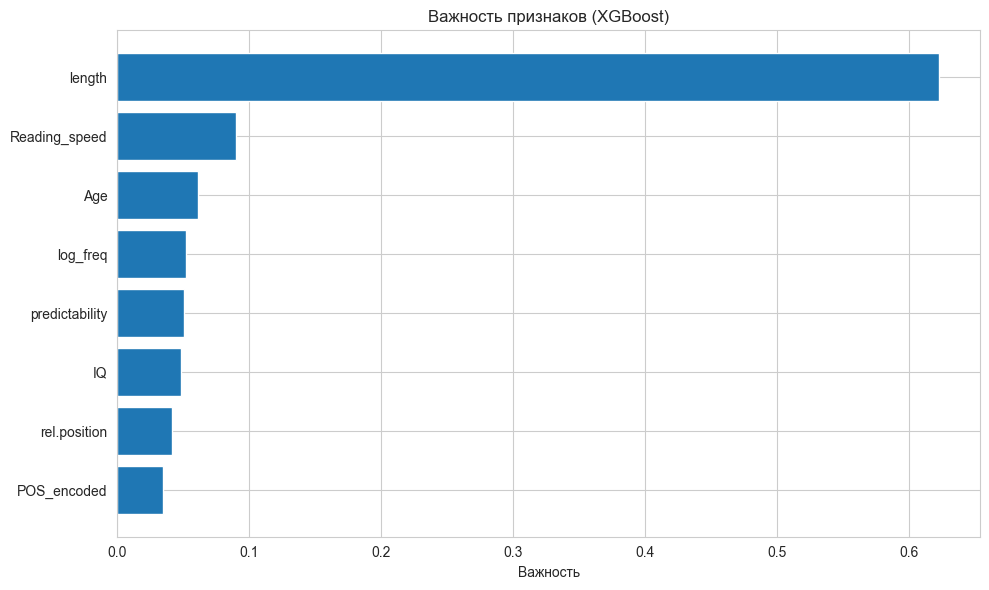

In [48]:
# ============================================
# ПРЕДСКАЗАТЕЛЬНАЯ МОДЕЛЬ ДЛЯ IA_DWELL_TIME
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 1. Подготовка данных
# ---------------------
# Создаем копию с нужными колонками
model_df = df[['Age', 'IQ', 'Reading_speed', 'length', 'log_freq', 
               'predictability', 'rel.position', 'POS', 'IA_DWELL_TIME']].copy()

# Удаляем строки с пропусками
model_df = model_df.dropna()

# Кодируем категориальную переменную POS (часть речи)
le = LabelEncoder()
model_df['POS_encoded'] = le.fit_transform(model_df['POS'])

# Выбираем признаки (без оригинального POS)
features = ['Age', 'IQ', 'Reading_speed', 'length', 'log_freq', 
            'predictability', 'rel.position', 'POS_encoded']

X = model_df[features]
y = model_df['IA_DWELL_TIME']

# Логарифмируем целевую переменную (так как распределение скошено)
y_log = np.log1p(y)  # log(1 + time)

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Масштабируем признаки (важно для линейных моделей)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Среднее время фиксации (лог): {y_train.mean():.3f}\n")

# 2. Обучаем разные модели и сравниваем
# ---------------------------------------
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    # Обучаем
    if name in ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)']:
        model.fit(X_train_scaled, y_train)
        y_pred_log = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test)
    
    # Преобразуем обратно в исходные мс
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)
    
    # Метрики
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Кросс-валидация (для Tree-based моделей)
    if name not in ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)']:
        cv_scores = cross_val_score(model, X, y_log, cv=5, scoring='r2')
        cv_mean = cv_scores.mean()
    else:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
        cv_mean = cv_scores.mean()
    
    results.append({
        'Model': name,
        'MAE (мс)': f"{mae:.1f}",
        'RMSE (мс)': f"{rmse:.1f}",
        'R²': f"{r2:.3f}",
        'CV R²': f"{cv_mean:.3f}"
    })

# Выводим таблицу сравнения
results_df = pd.DataFrame(results)
print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(results_df.to_string(index=False))

# 3. Выбираем лучшую модель и тюним гиперпараметры
# ------------------------------------------------
print("\n=== ТЮНИНГ ЛУЧШЕЙ МОДЕЛИ (XGBoost) ===")

# Для XGBoost подбираем параметры
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший R² на CV: {grid_search.best_score_:.4f}")

# Оцениваем на тесте
best_xgb = grid_search.best_estimator_
y_pred_log = best_xgb.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print(f"\nФинальная оценка на тестовой выборке:")
print(f"  R²: {r2_score(y_true, y_pred):.4f}")
print(f"  MAE: {mean_absolute_error(y_true, y_pred):.1f} мс")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.1f} мс")

# 4. Анализ важности признаков (Feature Importance)
# -------------------------------------------------
print("\n=== ВАЖНОСТЬ ПРИЗНАКОВ ===")

# Для XGBoost
importance = best_xgb.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Визуализация
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Важность')
plt.title('Важность признаков (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [49]:
import joblib

# Сохраняем модель и скейлер
joblib.dump(best_xgb, 'fixation_model.pkl')
joblib.dump(scaler, 'scaler.pkl')  # если использовали масштабирование для линейных моделей, но для XGBoost не обязательно

# Сохраняем также список признаков и метаданные
metadata = {
    'features': features,
    'pos_mapping': dict(enumerate(le.classes_)),  # если использовали LabelEncoder
    'target_mean': y_train.mean(),
    'target_std': y_train.std()
}
joblib.dump(metadata, 'model_metadata.pkl')

print("Модель и метаданные сохранены!")

Модель и метаданные сохранены!


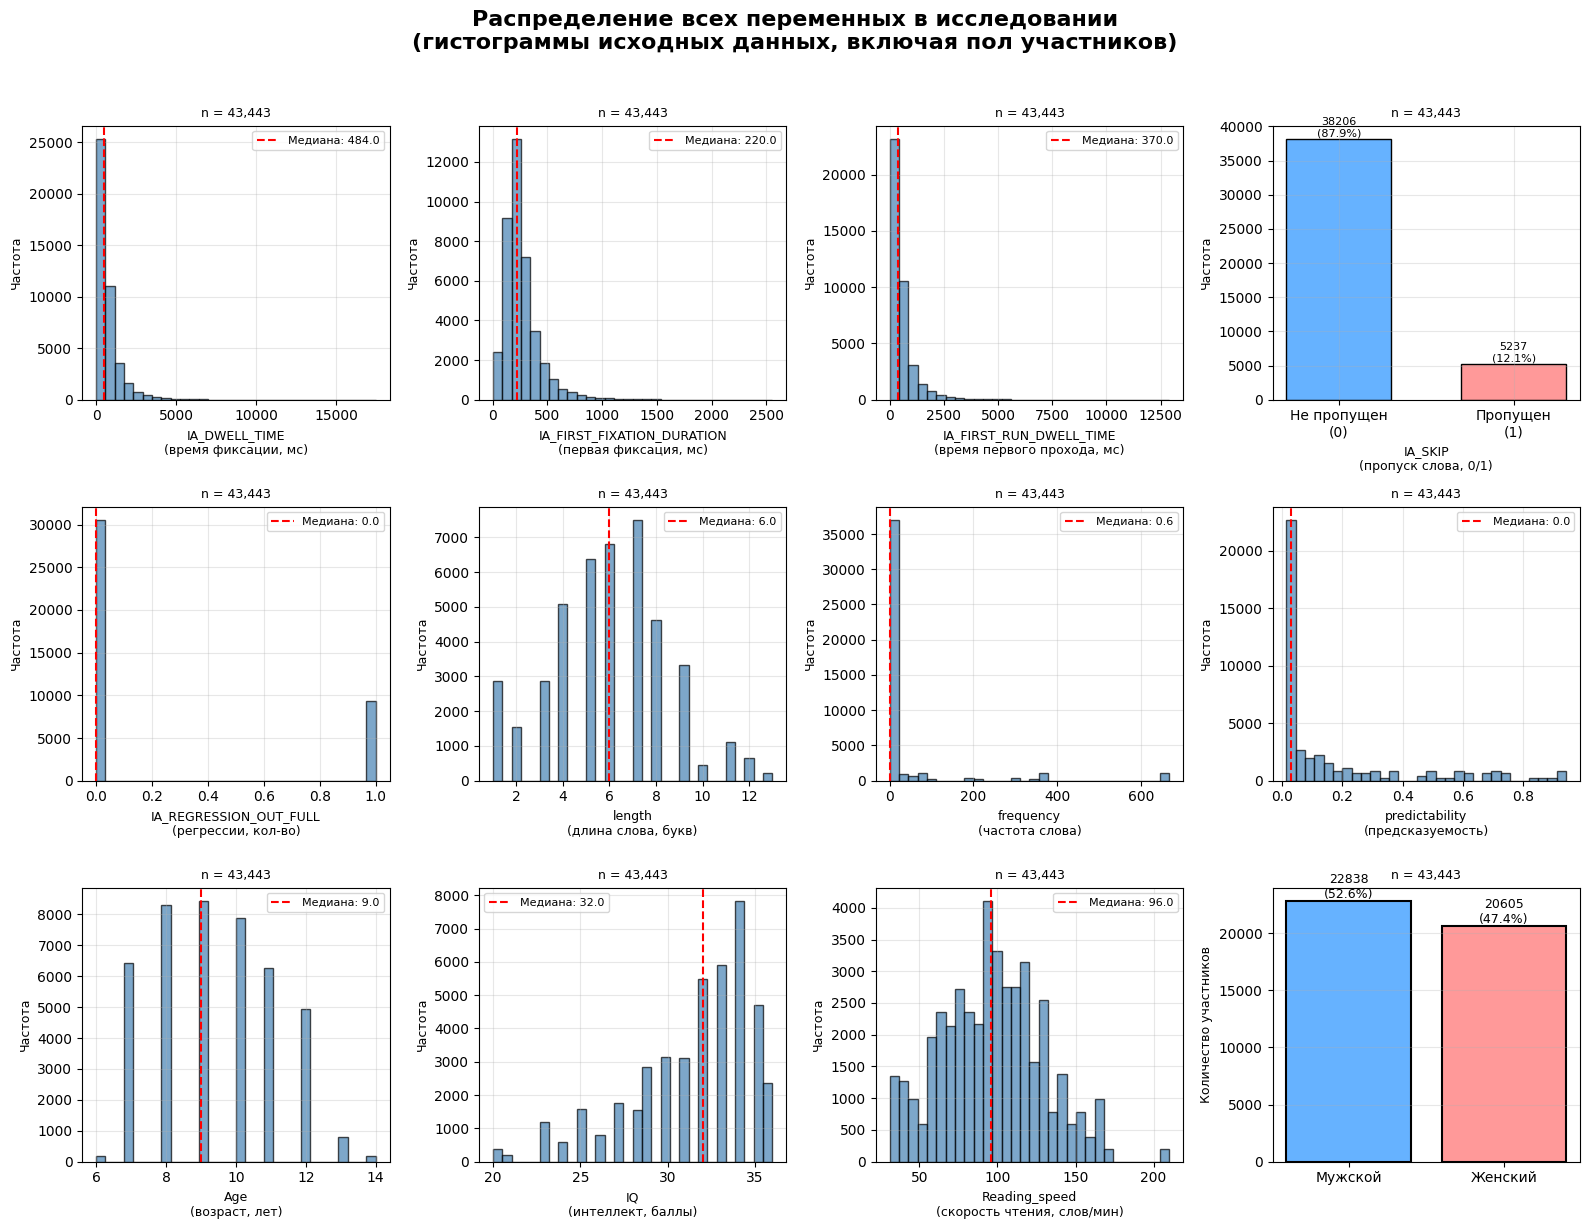

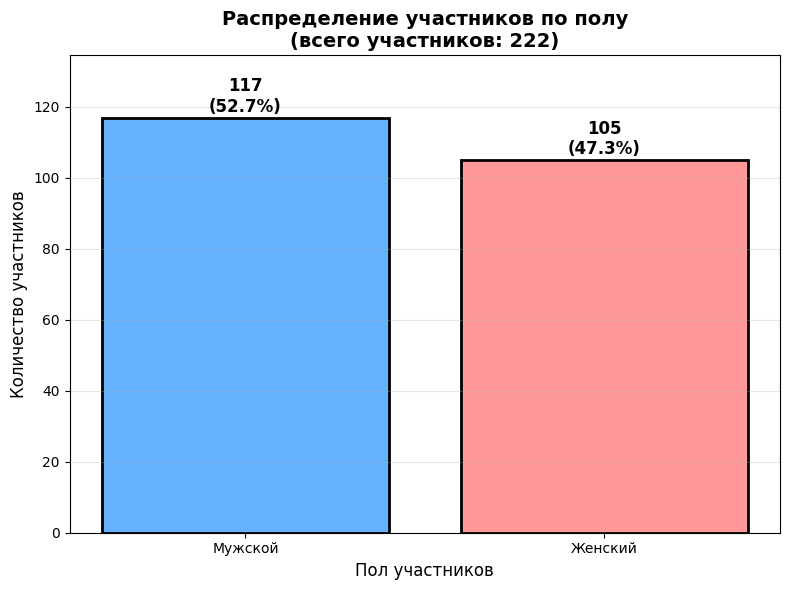


ОСНОВНЫЕ СТАТИСТИКИ ПО ВСЕМ ПЕРЕМЕННЫМ

IA_DWELL_TIME (время фиксации, мс):
  Количество наблюдений: 43,443
  Среднее: 723.05
  Медиана: 484.00
  Стандартное отклонение: 843.65
  Минимум: 0.00
  Максимум: 17451.00
  25-й перцентиль: 263.00
  75-й перцентиль: 877.00

IA_FIRST_FIXATION_DURATION (первая фиксация, мс):
  Количество наблюдений: 39,971
  Среднее: 260.83
  Медиана: 220.00
  Стандартное отклонение: 169.50
  Минимум: 1.00
  Максимум: 2557.00
  25-й перцентиль: 164.00
  75-й перцентиль: 311.00

IA_FIRST_RUN_DWELL_TIME (время первого прохода, мс):
  Количество наблюдений: 39,971
  Среднее: 553.14
  Медиана: 370.00
  Стандартное отклонение: 592.82
  Минимум: 1.00
  Максимум: 12897.00
  25-й перцентиль: 226.00
  75-й перцентиль: 634.00

IA_SKIP (пропуск слова, 0/1):
  Количество наблюдений: 43,443
  Среднее: 0.12
  Медиана: 0.00
  Стандартное отклонение: 0.33
  Минимум: 0.00
  Максимум: 1.00
  25-й перцентиль: 0.00
  75-й перцентиль: 0.00

IA_REGRESSION_OUT_FULL (регрессии, кол-во

In [1]:
# ============================================
# ГИСТОГРАММЫ РАСПРЕДЕЛЕНИЯ ВСЕХ ПЕРЕМЕННЫХ
# 12 гистограмм на одном графике (включая пол)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data_path = "./Data/"
data = pd.read_csv(data_path + "data.csv", sep=';', encoding='utf-8')
participants = pd.read_csv(data_path + "participants.csv", sep=',', encoding='utf-8')
sentences = pd.read_csv(data_path + "sentences.csv", sep=',', encoding='utf-8')
words = pd.read_csv(data_path + "words.csv", sep=',', encoding='utf-8')
ia_raw = pd.read_csv(data_path + "IA_children_norm.csv", sep=',', encoding='utf-8')

# Объединение данных
df = pd.merge(data, participants, on='SubjID', how='left')

# Очистка и подготовка
if 'Grade_y' in df.columns:
    df['Grade'] = df['Grade_y']
elif 'Grade_x' in df.columns:
    df['Grade'] = df['Grade_x']

df = df.dropna(subset=['Grade'])
df['Grade'] = df['Grade'].astype(int)
df = df[df['Grade'].between(1, 6)]

# Приводим все колонки к числовому типу
numeric_cols_all = ['IA_DWELL_TIME', 'IA_FIRST_FIXATION_DURATION', 'IA_FIRST_RUN_DWELL_TIME',
                    'IA_SKIP', 'IA_REGRESSION_OUT_FULL', 'one_fix', 'twoplus_fix', 
                    'landing', 'fsa', 'length', 'frequency', 'predictability', 
                    'Age', 'IQ', 'Reading_speed', 'Sound_change_x', 'Sound_change_y',
                    'rel.position', 'item.id', 'Grade']

for col in numeric_cols_all:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ============================================
# ВЫБИРАЕМ 12 ПЕРЕМЕННЫХ ДЛЯ ГИСТОГРАММ (включая пол)
# ============================================

# Список переменных (ТОЛЬКО исходные данные, без расчетных)
variables = [
    'IA_DWELL_TIME',              # Время фиксации на слове
    'IA_FIRST_FIXATION_DURATION', # Длительность первой фиксации
    'IA_FIRST_RUN_DWELL_TIME',    # Время первого прохода
    'IA_SKIP',                    # Пропуск слова (0/1)
    'IA_REGRESSION_OUT_FULL',     # Регрессии
    'length',                     # Длина слова
    'frequency',                  # Частота слова
    'predictability',             # Предсказуемость
    'Age',                        # Возраст
    'IQ',                         # IQ
    'Reading_speed',              # Скорость чтения
    'Sex'                         # Пол (добавлен)
]

# Названия переменных для подписей (на русском)
labels = [
    'IA_DWELL_TIME\n(время фиксации, мс)',
    'IA_FIRST_FIXATION_DURATION\n(первая фиксация, мс)',
    'IA_FIRST_RUN_DWELL_TIME\n(время первого прохода, мс)',
    'IA_SKIP\n(пропуск слова, 0/1)',
    'IA_REGRESSION_OUT_FULL\n(регрессии, кол-во)',
    'length\n(длина слова, букв)',
    'frequency\n(частота слова)',
    'predictability\n(предсказуемость)',
    'Age\n(возраст, лет)',
    'IQ\n(интеллект, баллы)',
    'Reading_speed\n(скорость чтения, слов/мин)',
    'Sex\n(пол участников)'
]

# Создаем фигуру с 12 подграфиками (3x4)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()  # Превращаем в одномерный массив

# Строим гистограммы для каждой переменной
for i, (var, label) in enumerate(zip(variables, labels)):
    # Получаем данные
    if var == 'Sex':
        # Для пола - категориальная переменная
        sex_counts = df[var].value_counts()
        # Переименовываем значения
        sex_labels = {'masc': 'Мужской', 'fem': 'Женский'}
        sex_names = [sex_labels.get(str(x), str(x)) for x in sex_counts.index]
        
        bars = axes[i].bar(sex_names, sex_counts.values, 
                          color=['#66B2FF', '#FF9999'], 
                          edgecolor='black', linewidth=1.5)
        
        # Добавляем проценты на столбцы
        total = len(df[var].dropna())
        for bar, count in zip(bars, sex_counts.values):
            percentage = (count / total) * 100
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                        f'{count}\n({percentage:.1f}%)', 
                        ha='center', va='bottom', fontsize=9)
        
        axes[i].set_ylabel('Количество участников', fontsize=9)
        axes[i].set_title(f'n = 43,443', fontsize=9)
        axes[i].grid(True, alpha=0.3, axis='y')
        
    else:
        # Для числовых переменных
        data_clean = df[var].dropna()
        
        if len(data_clean) > 0:
            # Для бинарной переменной IA_SKIP показываем как столбцы
            if var == 'IA_SKIP':
                unique_vals = data_clean.unique()
                if len(unique_vals) <= 2:  # Бинарная переменная
                    counts = data_clean.value_counts().sort_index()
                    bars = axes[i].bar(counts.index.astype(str), counts.values, 
                                      color=['#66B2FF', '#FF9999'], 
                                      edgecolor='black', width=0.6)
                    axes[i].set_xticks([0, 1])
                    axes[i].set_xticklabels(['Не пропущен\n(0)', 'Пропущен\n(1)'])
                    axes[i].set_ylabel('Частота', fontsize=9)
                    
                    # Добавляем проценты
                    total = len(data_clean)
                    for bar, count in zip(bars, counts.values):
                        percentage = (count / total) * 100
                        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                                    f'{count}\n({percentage:.1f}%)', 
                                    ha='center', va='bottom', fontsize=8)
                else:
                    axes[i].hist(data_clean, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
                    # Добавляем медиану
                    median_val = data_clean.median()
                    axes[i].axvline(median_val, color='red', linestyle='--', linewidth=1.5, 
                                   label=f'Медиана: {median_val:.1f}')
                    axes[i].legend(fontsize=8)
            else:
                # Для непрерывных переменных - гистограмма
                axes[i].hist(data_clean, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
                
                # Добавляем вертикальную линию медианы
                median_val = data_clean.median()
                axes[i].axvline(median_val, color='red', linestyle='--', linewidth=1.5, 
                               label=f'Медиана: {median_val:.1f}')
                axes[i].legend(fontsize=8)
            
            axes[i].set_xlabel(label, fontsize=9)
            axes[i].set_ylabel('Частота', fontsize=9)
            axes[i].set_title(f'n = 43,443', fontsize=9)
            axes[i].grid(True, alpha=0.3)
        else:
            axes[i].text(0.5, 0.5, f'Нет данных для\n{var}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_xlabel(label, fontsize=9)

# Общий заголовок
plt.suptitle('Распределение всех переменных в исследовании\n(гистограммы исходных данных, включая пол участников)', 
             fontsize=16, fontweight='bold', y=1.02)

# Настройка отступов
plt.tight_layout()
plt.show()

# ============================================
# ДОПОЛНИТЕЛЬНО: ОТДЕЛЬНЫЙ ГРАФИК ДЛЯ ПОЛА (более детальный)
# ============================================

fig, ax = plt.subplots(figsize=(8, 6))

# Данные по полу (уникальные участники, а не наблюдения)
unique_participants = df.drop_duplicates(subset=['SubjID'])
sex_counts_unique = unique_participants['Sex'].value_counts()

sex_labels_unique = {'masc': 'Мужской', 'fem': 'Женский'}
sex_names_unique = [sex_labels_unique.get(str(x), str(x)) for x in sex_counts_unique.index]

colors = ['#66B2FF', '#FF9999']
bars = ax.bar(sex_names_unique, sex_counts_unique.values, 
              color=colors, edgecolor='black', linewidth=2)

# Добавляем проценты на столбцы
total_unique = len(unique_participants)
for bar, count in zip(bars, sex_counts_unique.values):
    percentage = (count / total_unique) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{count}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Пол участников', fontsize=12)
ax.set_ylabel('Количество участников', fontsize=12)
ax.set_title(f'Распределение участников по полу\n(всего участников: {total_unique})', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(sex_counts_unique.values) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================
# ВЫВОД ОСНОВНЫХ СТАТИСТИК
# ============================================

print("\n" + "="*80)
print("ОСНОВНЫЕ СТАТИСТИКИ ПО ВСЕМ ПЕРЕМЕННЫМ")
print("="*80)

for var, label in zip(variables, labels):
    if var == 'Sex':
        # Статистика по полу (уникальные участники)
        unique_participants = df.drop_duplicates(subset=['SubjID'])
        sex_counts = unique_participants['Sex'].value_counts()
        print(f"\n{label.replace(chr(10), ' ')}:")
        print(f"  Общее количество участников: {len(unique_participants)}")
        for sex, count in sex_counts.items():
            sex_name = 'Мужской' if sex == 'masc' else 'Женский' if sex == 'fem' else sex
            print(f"  {sex_name}: {count} ({count/len(unique_participants)*100:.1f}%)")
    else:
        data_clean = df[var].dropna()
        if len(data_clean) > 0:
            print(f"\n{label.replace(chr(10), ' ')}:")
            print(f"  Количество наблюдений: {len(data_clean):,}")
            print(f"  Среднее: {data_clean.mean():.2f}")
            print(f"  Медиана: {data_clean.median():.2f}")
            print(f"  Стандартное отклонение: {data_clean.std():.2f}")
            print(f"  Минимум: {data_clean.min():.2f}")
            print(f"  Максимум: {data_clean.max():.2f}")
            print(f"  25-й перцентиль: {data_clean.quantile(0.25):.2f}")
            print(f"  75-й перцентиль: {data_clean.quantile(0.75):.2f}")

# Дополнительная информация по выборке
print("\n" + "="*80)
print("ИНФОРМАЦИЯ О ВЫБОРКЕ УЧАСТНИКОВ")
print("="*80)

unique_participants = df.drop_duplicates(subset=['SubjID'])
print(f"Всего уникальных участников: {len(unique_participants)}")
print(f"Распределение по классам:")
for grade in sorted(unique_participants['Grade'].unique()):
    count = len(unique_participants[unique_participants['Grade'] == grade])
    print(f"  {grade} класс: {count} участников ({count/len(unique_participants)*100:.1f}%)")

print("\n✅ Готово! Создано 2 графика:")
print("  1. Основной график - 12 гистограмм на одной странице (включая пол)")
print("  2. Детальный график распределения участников по полу")
print("  3. Выведены основные статистики для всех переменных")